In [1]:
!pip -q install albumentations opencv-python --upgrade

In [2]:
import os, random
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.auto import tqdm

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [4]:
from google.colab import drive
drive.mount("/content/drive")

base_path = r"/content/drive/MyDrive/ML_MED/Practical3/Practical_3"
print("base_path:", base_path)

lung_dir = os.path.join(base_path, "Lung Segmentation Data")
inf_dir  = os.path.join(base_path, "Infection Segmentation Data")

def resolve_dataset_root(p):
    p = Path(p)
    if not p.is_dir():
        return p

    children = [c for c in p.iterdir() if c.is_dir()]
    for c in children:
        if (c / "Train").is_dir() and (c / "Val").is_dir() and (c / "Test").is_dir():
            return c

    return p

LUNG_ROOT = resolve_dataset_root(lung_dir)
INF_ROOT  = resolve_dataset_root(inf_dir)

print("LUNG_ROOT:", LUNG_ROOT)
print("INF_ROOT :", INF_ROOT)

SAVE_DIR = Path("/content/drive/MyDrive/Prac_3_checkpoints")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SAVE_DIR

Mounted at /content/drive
base_path: /content/drive/MyDrive/ML_MED/Practical3/Practical_3
LUNG_ROOT: /content/drive/MyDrive/ML_MED/Practical3/Practical_3/Lung Segmentation Data/Lung Segmentation Data
INF_ROOT : /content/drive/MyDrive/ML_MED/Practical3/Practical_3/Infection Segmentation Data/Infection Segmentation Data


PosixPath('/content/drive/MyDrive/Prac_3_checkpoints')

In [5]:
IMG_EXTS = (".png",".jpg",".jpeg",".tif",".tiff",".bmp")

def list_imgs(folder: Path):
    out = []
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(IMG_EXTS):
                out.append(str(Path(root)/f))
    return sorted(out)

def safe_read_gray(p: str):
    im = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if im is None:
        raise FileNotFoundError(p)
    return im

In [6]:
IMG_SIZE = 256
tfm = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    ToTensorV2()
])

In [7]:
def build_pairs(root_dir: Path, split: str, mask_folder_name: str):
    pairs = []
    split_dir = root_dir / split
    if not split_dir.is_dir():
        print("Missing:", split_dir)
        return pairs
    classes = [d for d in split_dir.iterdir() if d.is_dir()]
    for cls_dir in classes:
        img_dir = cls_dir / "images"
        msk_dir = cls_dir / mask_folder_name
        if (not img_dir.is_dir()) or (not msk_dir.is_dir()):
            continue
        imgs = list_imgs(img_dir)
        for ip in imgs:
            mp = str(msk_dir / (Path(ip).name))
            if Path(mp).is_file():
                pairs.append((ip, mp))
    return pairs

lung_train = build_pairs(LUNG_ROOT, "Train", "lung masks")
lung_val   = build_pairs(LUNG_ROOT, "Val",   "lung masks")
lung_test  = build_pairs(LUNG_ROOT, "Test",  "lung masks")

print("Lung pairs:", len(lung_train), len(lung_val), len(lung_test))

Lung pairs: 21715 5417 6788


In [8]:
def build_infection_items(root_dir: Path, split: str):
    items = []
    split_dir = root_dir / split
    if not split_dir.is_dir():
        print("Missing:", split_dir)
        return items
    classes = [d for d in split_dir.iterdir() if d.is_dir()]
    for cls_dir in classes:
        img_dir = cls_dir / "images"
        lung_dir = cls_dir / "lung masks"
        inf_dir  = cls_dir / "infection masks"
        if (not img_dir.is_dir()) or (not lung_dir.is_dir()) or (not inf_dir.is_dir()):
            continue
        imgs = list_imgs(img_dir)
        for ip in imgs:
            lp = str(lung_dir / Path(ip).name)
            fp = str(inf_dir / Path(ip).name)
            if Path(lp).is_file() and Path(fp).is_file():
                items.append((ip, lp, fp))
    return items

inf_train = build_infection_items(INF_ROOT, "Train")
inf_val   = build_infection_items(INF_ROOT, "Val")
inf_test  = build_infection_items(INF_ROOT, "Test")

print("Infection items:", len(inf_train), len(inf_val), len(inf_test))

Infection items: 3728 932 1166


In [9]:
class LungSegDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        ip, mp = self.pairs[idx]
        img = safe_read_gray(ip).astype(np.float32) / 255.0
        msk = safe_read_gray(mp).astype(np.float32)
        msk = (msk > 127).astype(np.float32)
        aug = self.transform(image=img, mask=msk)
        x = aug["image"].float().unsqueeze(0) if aug["image"].ndim==2 else aug["image"].float()
        y = aug["mask"].float().unsqueeze(0) if aug["mask"].ndim==2 else aug["mask"].float()
        return x, y

class InfectionSegDataset(Dataset):
    def __init__(self, items, transform):
        self.items = items
        self.transform = transform
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        ip, lp, fp = self.items[idx]
        img = safe_read_gray(ip).astype(np.float32) / 255.0
        lung = safe_read_gray(lp).astype(np.float32)
        inf  = safe_read_gray(fp).astype(np.float32)
        lung = (lung > 127).astype(np.float32)
        inf  = (inf  > 127).astype(np.float32)
        img = img * lung
        aug = self.transform(image=img, mask=inf)
        x = aug["image"].float().unsqueeze(0) if aug["image"].ndim==2 else aug["image"].float()
        y = aug["mask"].float().unsqueeze(0) if aug["mask"].ndim==2 else aug["mask"].float()
        return x, y

In [10]:
def make_loaders(train_data, val_data, test_data, batch_size=32, num_workers=2):
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True, drop_last=False)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True, drop_last=False)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True, drop_last=False)
    return train_loader, val_loader, test_loader

In [11]:
def dice_coef_from_logits(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    targets = targets.float()
    inter = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
    dice = (2*inter + eps) / (union + eps)
    return dice.mean().item()

def iou_coef_from_logits(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    targets = targets.float()
    inter = (preds * targets).sum(dim=(1,2,3))
    total = (preds + targets).sum(dim=(1,2,3))
    union = total - inter
    iou = (inter + eps) / (union + eps)
    return iou.mean().item()

In [12]:
class DWConv(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.dw = nn.Conv2d(c_in, c_in, 3, padding=1, groups=c_in, bias=False)
        self.pw = nn.Conv2d(c_in, c_out, 1, bias=False)
        self.bn = nn.BatchNorm2d(c_out)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))

class TinyUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=16):
        super().__init__()
        c1, c2, c3, c4 = base, base*2, base*4, base*8

        self.enc1 = nn.Sequential(DWConv(in_ch, c1), DWConv(c1, c1))
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(DWConv(c1, c2), DWConv(c2, c2))
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = nn.Sequential(DWConv(c2, c3), DWConv(c3, c3))
        self.pool3 = nn.MaxPool2d(2)

        self.bott = nn.Sequential(DWConv(c3, c4), DWConv(c4, c4))

        self.up3 = nn.ConvTranspose2d(c4, c3, 2, stride=2)
        self.dec3 = nn.Sequential(DWConv(c3+c3, c3), DWConv(c3, c3))

        self.up2 = nn.ConvTranspose2d(c3, c2, 2, stride=2)
        self.dec2 = nn.Sequential(DWConv(c2+c2, c2), DWConv(c2, c2))

        self.up1 = nn.ConvTranspose2d(c2, c1, 2, stride=2)
        self.dec1 = nn.Sequential(DWConv(c1+c1, c1), DWConv(c1, c1))

        self.head = nn.Conv2d(c1, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b  = self.bott(self.pool3(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.head(d1)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

m_tmp = TinyUNet(base=16)
print("TinyUNet params:", count_params(m_tmp))

TinyUNet params: 99402


In [13]:
def save_checkpoint(path, model, opt, epoch, best_metric, history):
    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "opt_state": opt.state_dict(),
        "best_metric": best_metric,
        "history": history,
        "torch_version": torch.__version__,
    }
    torch.save(ckpt, path)

def load_checkpoint(path, model, opt=None, map_location="cpu"):
    ckpt = torch.load(path, map_location=map_location,weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    if opt is not None and "opt_state" in ckpt:
        opt.load_state_dict(ckpt["opt_state"])
    return ckpt

In [14]:
@torch.no_grad()
def eval_epoch(model, loader, loss_fn):
    model.eval()
    losses, dices, ious = [], [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = loss_fn(logits, y)
        losses.append(loss.item())
        dices.append(dice_coef_from_logits(logits, y))
        ious.append(iou_coef_from_logits(logits, y))
    return float(np.mean(losses)), float(np.mean(dices)), float(np.mean(ious))

def train_epoch(model, loader, opt, loss_fn, scaler=None):
    model.train()
    losses, dices, ious = [], [], []
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad(set_to_none=True)
        if scaler is None:
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()
        else:
            with torch.amp.autocast(device_type="cuda", enabled=(DEVICE.type=="cuda")):
                logits = model(x)
                loss = loss_fn(logits, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
        losses.append(loss.item())
        dices.append(dice_coef_from_logits(logits, y))
        ious.append(iou_coef_from_logits(logits, y))
    return float(np.mean(losses)), float(np.mean(dices)), float(np.mean(ious))

In [15]:
def fit_stage(stage_name, model, train_loader, val_loader, epochs, lr, ckpt_name):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler(enabled=(DEVICE.type=="cuda"))

    ckpt_path = SAVE_DIR / ckpt_name
    best_path = SAVE_DIR / (ckpt_name.replace(".pt", "_best.pth"))
    history = {"train_loss":[], "train_dice":[], "train_iou":[],
               "val_loss":[], "val_dice":[], "val_iou":[]}

    start_epoch = 0
    best_dice = -1.0

    if ckpt_path.exists():
        ckpt = load_checkpoint(ckpt_path, model, opt, map_location=DEVICE)
        start_epoch = int(ckpt.get("epoch", 0)) + 1
        best_dice = float(ckpt.get("best_metric", -1.0))
        history = ckpt.get("history", history)
        print(f"[{stage_name}] Resumed from epoch {start_epoch}, best_dice={best_dice:.4f}")

    for epoch in range(start_epoch, epochs):
        tr_loss, tr_dice, tr_iou = train_epoch(model, train_loader, opt, loss_fn, scaler=scaler)
        va_loss, va_dice, va_iou = eval_epoch(model, val_loader, loss_fn)

        history["train_loss"].append(tr_loss)
        history["train_dice"].append(tr_dice)
        history["train_iou"].append(tr_iou)
        history["val_loss"].append(va_loss)
        history["val_dice"].append(va_dice)
        history["val_iou"].append(va_iou)

        if va_dice > best_dice:
            best_dice = va_dice
            torch.save(model.state_dict(), best_path)

        save_checkpoint(ckpt_path, model, opt, epoch, best_dice, history)

        print(f"[{stage_name}] Epoch {epoch+1}/{epochs}  "
              f"train_loss={tr_loss:.4f} dice={tr_dice:.4f} iou={tr_iou:.4f} | "
              f"val_loss={va_loss:.4f} dice={va_dice:.4f} iou={va_iou:.4f} | "
              f"best_dice={best_dice:.4f}")

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return model, history, best_path

In [17]:
BATCH_SIZE = 32
NUM_WORKERS = 2

lung_train_ds = LungSegDataset(lung_train, tfm)
lung_val_ds   = LungSegDataset(lung_val, tfm)
lung_test_ds  = LungSegDataset(lung_test, tfm)

lung_train_loader, lung_val_loader, lung_test_loader = make_loaders(
    lung_train_ds, lung_val_ds, lung_test_ds,
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS
)

lung_model = TinyUNet(in_ch=1, out_ch=1, base=16)
print("Stage A params:", count_params(lung_model))

lung_model, lung_hist, lung_best = fit_stage(
    "LUNG", lung_model, lung_train_loader, lung_val_loader,
    epochs=30, lr=1e-3, ckpt_name="stageA_lung_resume.pt"
)

print("Saved best:", lung_best)

Stage A params: 99402
[LUNG] Resumed from epoch 24, best_dice=0.9749


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/679 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [27]:
loss_fn = nn.BCEWithLogitsLoss()
test_loss, test_dice, test_iou = eval_epoch(lung_model, lung_test_loader, loss_fn)
print("Stage A TEST:", {"loss": test_loss, "dice": test_dice, "iou": test_iou})

Stage A TEST: {'loss': 0.03599582269280589, 'dice': 0.9683055471926229, 'iou': 0.9405736702148904}


In [18]:
BATCH_SIZE = 32
NUM_WORKERS = 2

In [19]:
inf_train_ds = InfectionSegDataset(inf_train, tfm)
inf_val_ds   = InfectionSegDataset(inf_val, tfm)
inf_test_ds  = InfectionSegDataset(inf_test, tfm)

inf_train_loader, inf_val_loader, inf_test_loader = make_loaders(
    inf_train_ds, inf_val_ds, inf_test_ds,
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS
)

inf_model = TinyUNet(in_ch=1, out_ch=1, base=16)
print("Stage B params:", count_params(inf_model))

inf_model, inf_hist, inf_best = fit_stage(
    "INFECTION", inf_model, inf_train_loader, inf_val_loader,
    epochs=30, lr=1e-3, ckpt_name="stageB_infection_resume.pt"
)

print("Saved best:", inf_best)

Stage B params: 99402
[INFECTION] Resumed from epoch 30, best_dice=0.8346
Saved best: /content/drive/MyDrive/Prac_3_checkpoints/stageB_infection_resume_best.pth


In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
test_loss, test_dice, test_iou = eval_epoch(inf_model, inf_test_loader, loss_fn)
print("Stage B TEST:", {"loss": test_loss, "dice": test_dice, "iou": test_iou})

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Stage B TEST: {'loss': 0.062124045162990284, 'dice': 0.8277042781984484, 'iou': 0.7688686396624591}


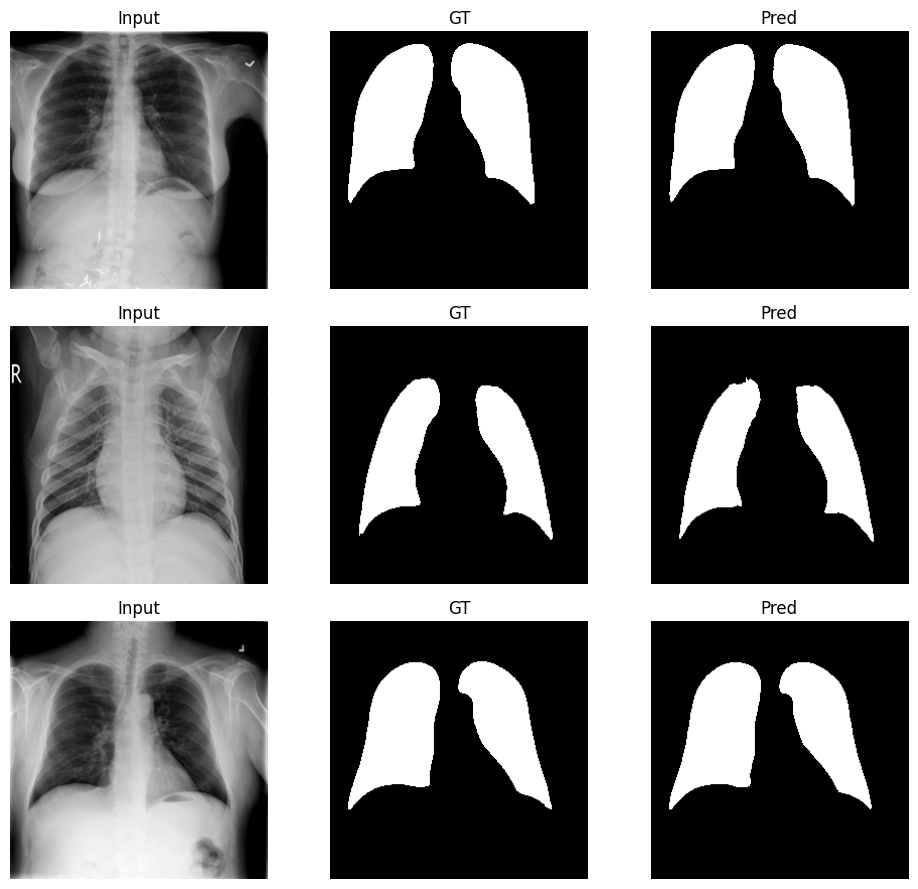

In [ ]:
def show_batch(model, loader, n=3):
    import matplotlib.pyplot as plt
    model.eval()
    x, y = next(iter(loader))
    x = x.to(DEVICE)
    with torch.no_grad():
        p = torch.sigmoid(model(x)).cpu().numpy()
    x = x.cpu().numpy()
    y = y.numpy()
    k = min(n, x.shape[0])
    plt.figure(figsize=(10, 3*k))
    for i in range(k):
        img = x[i,0]
        gt  = y[i,0]
        pr  = (p[i,0] > 0.5).astype(np.float32)
        plt.subplot(k,3,3*i+1); plt.imshow(img, cmap="gray"); plt.axis("off"); plt.title("Input")
        plt.subplot(k,3,3*i+2); plt.imshow(gt, cmap="gray"); plt.axis("off"); plt.title("GT")
        plt.subplot(k,3,3*i+3); plt.imshow(pr, cmap="gray"); plt.axis("off"); plt.title("Pred")
    plt.tight_layout()

show_batch(lung_model, lung_test_loader, n=3)

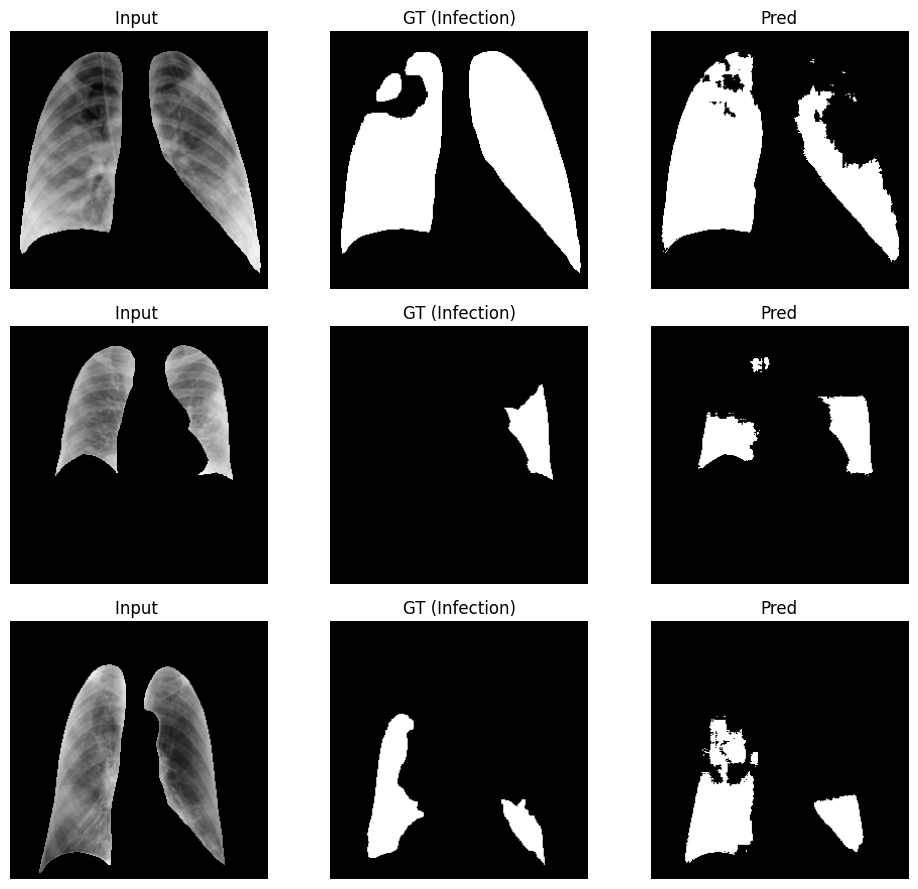

In [26]:
def show_batch_infection(model, loader, n=3):
    import matplotlib.pyplot as plt
    import numpy as np
    import torch

    model.eval()
    found_x, found_y = [], []


    for x_batch, y_batch in loader:
        for i in range(x_batch.shape[0]):
            if y_batch[i].max() > 0:
                found_x.append(x_batch[i])
                found_y.append(y_batch[i])
            if len(found_x) >= n: break
        if len(found_x) >= n: break

    if not found_x:
        print("Không tìm thấy mẫu có infection nào trong các batch được quét!")
        return


    x_tensor = torch.stack(found_x).to(DEVICE)
    with torch.no_grad():

        p = torch.sigmoid(model(x_tensor)).cpu().numpy()
        p_binary = (p > 0.5).astype(np.float32)

    plt.figure(figsize=(10, 3*n))
    for i in range(len(found_x)):
        img = found_x[i][0].numpy()
        gt  = found_y[i][0].numpy()
        pr  = p_binary[i, 0]


        plt.subplot(n, 3, 3*i+1)
        plt.imshow(img, cmap="gray")
        plt.title("Input ")
        plt.axis("off")


        plt.subplot(n, 3, 3*i+2)
        plt.imshow(gt, cmap="gray")
        plt.title("GT (Infection)")
        plt.axis("off")


        plt.subplot(n, 3, 3*i+3)
        plt.imshow(pr, cmap="gray")
        plt.title("Pred")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Sử dụng hàm này cho Stage B
show_batch_infection(inf_model, inf_test_loader, n=3)